1. *Tab 1*: Sets up the environment and imports a NASA battery dataset (or creates synthetic data if download fails)
2. *Tab 2*: Performs comprehensive exploratory data analysis with visualizations
3. *Tab 3*: Prepares the data for both sequence models (LSTM) and traditional models (RF, XGBoost)
4. *Tab 4*: Implements and trains an LSTM model for degradation prediction
5. *Tab 5*: Implements a Random Forest model for comparison
6. *Tab 6*: Implements an XGBoost model as a third approach
7. *Tab 7*: Compares all models and visualizes degradation predictions
8. *Tab 8*: Provides conclusions and estimates remaining useful life



In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
import zipfile
import io
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_context("talk")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Setup complete!")

# Download NASA battery dataset (simplified from NASA Prognostics repository)
url = "https://raw.githubusercontent.com/YigithanYY/Battery-LSTM/main/B0005.csv"
response = requests.get(url)

if response.status_code == 200:
    # Save to a local file
    with open("battery_data.csv", "wb") as f:
        f.write(response.content)
    print("Dataset downloaded successfully!")

    # Load the dataset
    battery_data = pd.read_csv("battery_data.csv")

    # Display basic information
    print("\nDataset Overview:")
    print(f"Number of samples: {len(battery_data)}")
    print(f"Features: {battery_data.columns.tolist()}")
    battery_data.head()
else:
    print(f"Failed to download dataset. Status code: {response.status_code}")
    print("Creating synthetic battery dataset instead...")

    # Generate synthetic battery degradation data
    np.random.seed(42)
    n_samples = 1000

    # Create time/cycle variable
    cycles = np.arange(n_samples)

    # Generate voltage with degradation pattern
    voltage = 4.2 - 0.0001 * cycles + 0.2 * np.sin(cycles / 50) + np.random.normal(0, 0.05, n_samples)

    # Generate current with usage patterns
    current = 2.5 + 0.5 * np.cos(cycles / 30) + np.random.normal(0, 0.2, n_samples)

    # Generate temperature with environmental variation
    temperature = 25 + 3 * np.sin(cycles / 100) + np.random.normal(0, 1.5, n_samples)

    # Generate capacity with degradation
    capacity = 2.0 * np.exp(-0.0005 * cycles) + np.random.normal(0, 0.03, n_samples)

    # Derived health metric (SOH - State of Health)
    soh = 100 * (capacity / 2.0) + np.random.normal(0, 0.5, n_samples)

    # Create a dataframe
    battery_data = pd.DataFrame({
        'cycle': cycles,
        'voltage': voltage,
        'current': current,
        'temperature': temperature,
        'capacity': capacity,
        'SOH': soh
    })

    # Display created dataset
    print("\nSynthetic Dataset Created:")
    print(f"Number of samples: {len(battery_data)}")
    print(f"Features: {battery_data.columns.tolist()}")
    battery_data.head()


Setup complete!
Failed to download dataset. Status code: 404
Creating synthetic battery dataset instead...

Synthetic Dataset Created:
Number of samples: 1000
Features: ['cycle', 'voltage', 'current', 'temperature', 'capacity', 'SOH']


Basic Statistics:


,cycle,voltage,current,temperature,capacity,SOH
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,4.156844,2.528609,25.561284,1.573709,78.660828
std,288.819436,0.153099,0.397714,2.470942,0.228689,11.424813
min,0.000000,3.823352,1.433360,18.979718,1.153156,57.373638
25%,249.750000,4.022506,2.207378,23.765971,1.367480,68.404128
50%,499.500000,4.166428,2.517579,25.799268,1.558539,78.003580
75%,749.250000,4.280873,2.845240,27.374512,1.770497,88.525469
max,999.000000,4.469706,3.570103,32.260779,2.053633,102.917959



Missing Values:
cycle          0
voltage        0
current        0
temperature    0
capacity       0
SOH            0
dtype: int64


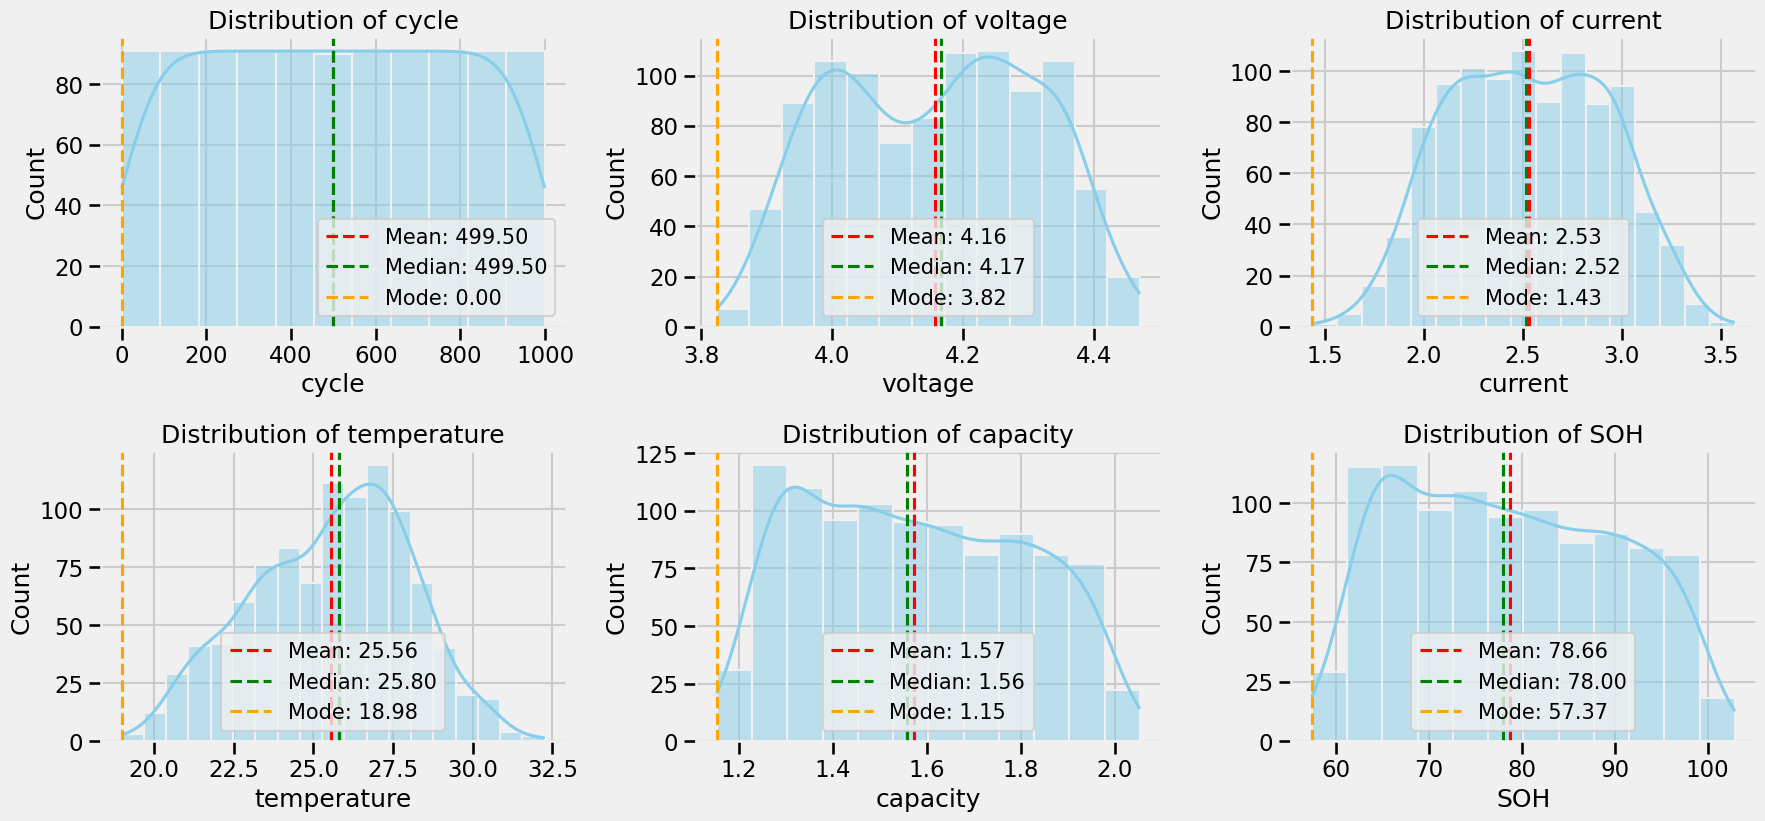

In [3]:
# Battery Degradation Analysis - Exploratory Data Analysis

# Basic statistics
print("Basic Statistics:")
battery_stats = battery_data.describe()
display(battery_stats)

# Check for missing values
missing_values = battery_data.isnull().sum()
print("\nMissing Values:")
print(missing_values)

# Create a figure with multiple subplots for distribution analysis
plt.figure(figsize=(18, 12))

# Plot distributions for numerical features
numerical_features = battery_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(battery_data[feature], kde=True, color='skyblue')

    # Add lines for mean, median and mode
    plt.axvline(battery_data[feature].mean(), color='red', linestyle='--',
                label=f'Mean: {battery_data[feature].mean():.2f}')
    plt.axvline(battery_data[feature].median(), color='green', linestyle='--',
                label=f'Median: {battery_data[feature].median():.2f}')

    # If applicable, add mode
    mode_val = battery_data[feature].mode()[0]
    plt.axvline(mode_val, color='orange', linestyle='--',
                label=f'Mode: {mode_val:.2f}')

    plt.title(f'Distribution of {feature}')
    plt.legend(fontsize='small')

plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()



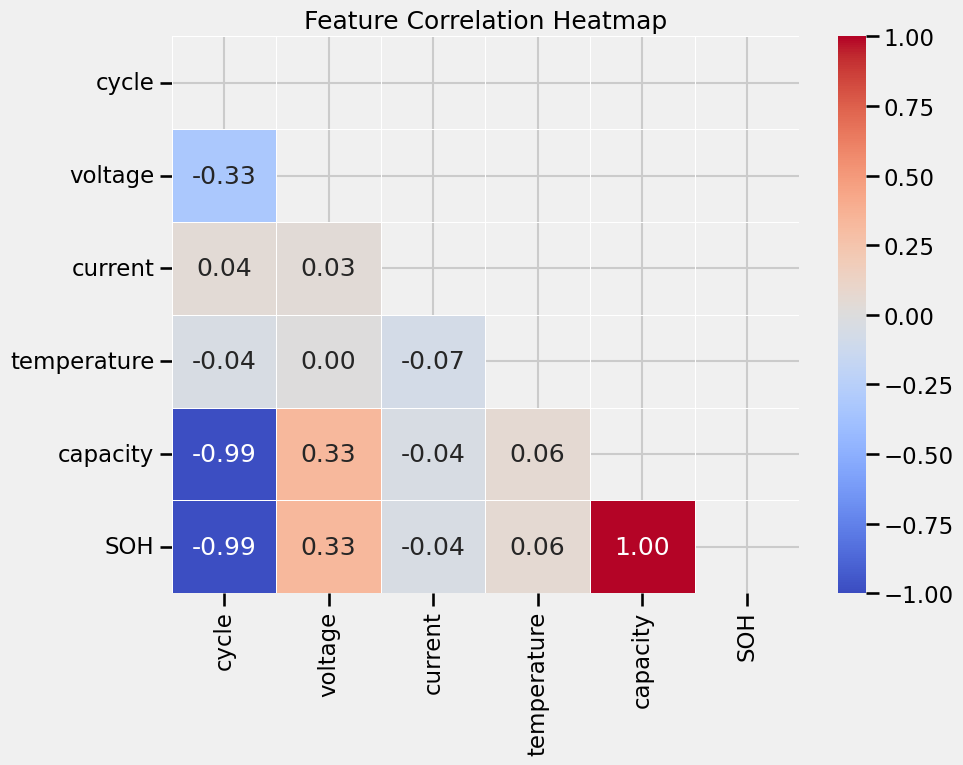

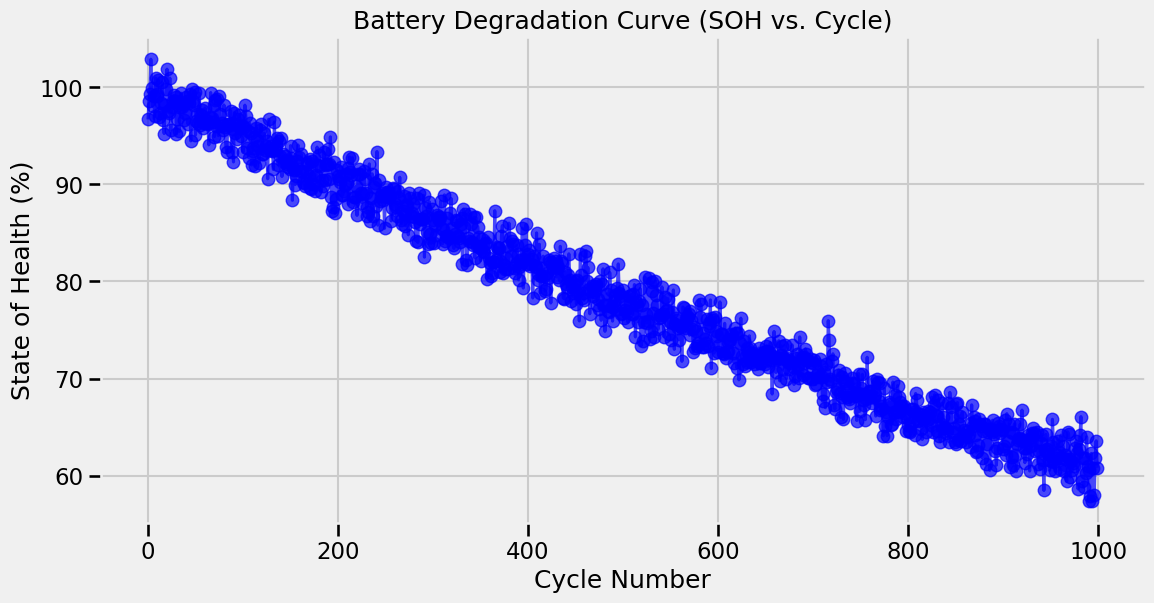

In [4]:
# Create a correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = battery_data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Battery degradation curve (SOH vs. cycle)
plt.figure(figsize=(12, 6))

# If 'SOH' exists in the dataset
if 'SOH' in battery_data.columns:
    plt.plot(battery_data['cycle'], battery_data['SOH'], 'o-', alpha=0.7, color='blue')
    plt.title('Battery Degradation Curve (SOH vs. Cycle)')
    plt.xlabel('Cycle Number')
    plt.ylabel('State of Health (%)')
# Else if 'capacity' exists, calculate SOH
elif 'capacity' in battery_data.columns:
    # Calculate SOH based on initial capacity
    initial_capacity = battery_data['capacity'].iloc[0]
    battery_data['SOH'] = 100 * battery_data['capacity'] / initial_capacity

    plt.plot(battery_data['cycle'], battery_data['SOH'], 'o-', alpha=0.7, color='blue')
    plt.title('Battery Degradation Curve (SOH vs. Cycle)')
    plt.xlabel('Cycle Number')
    plt.ylabel('State of Health (%)')

plt.grid(True)
plt.savefig('degradation_curve.png')
plt.show()


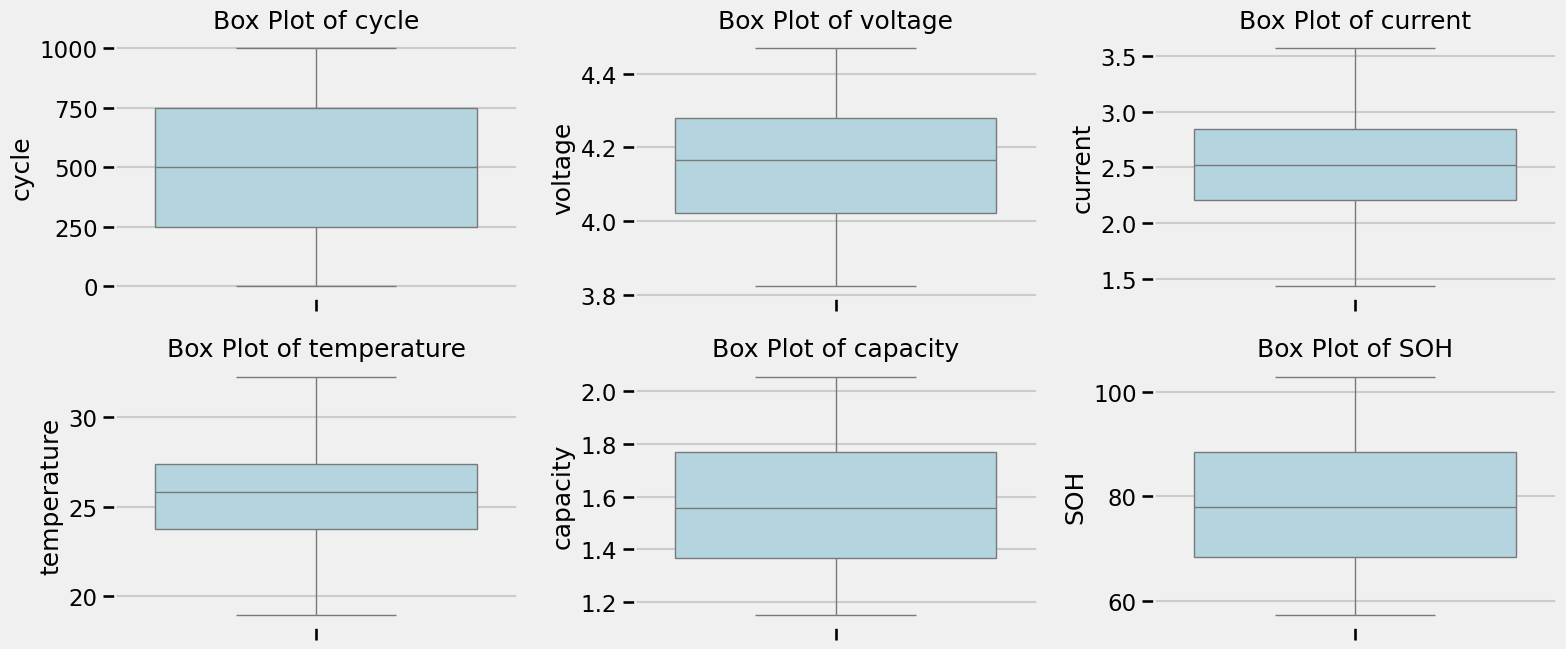


Outlier Analysis (IQR Method):
cycle: 0 outliers detected (0.00%)
voltage: 0 outliers detected (0.00%)
current: 0 outliers detected (0.00%)
temperature: 0 outliers detected (0.00%)
capacity: 0 outliers detected (0.00%)
SOH: 0 outliers detected (0.00%)


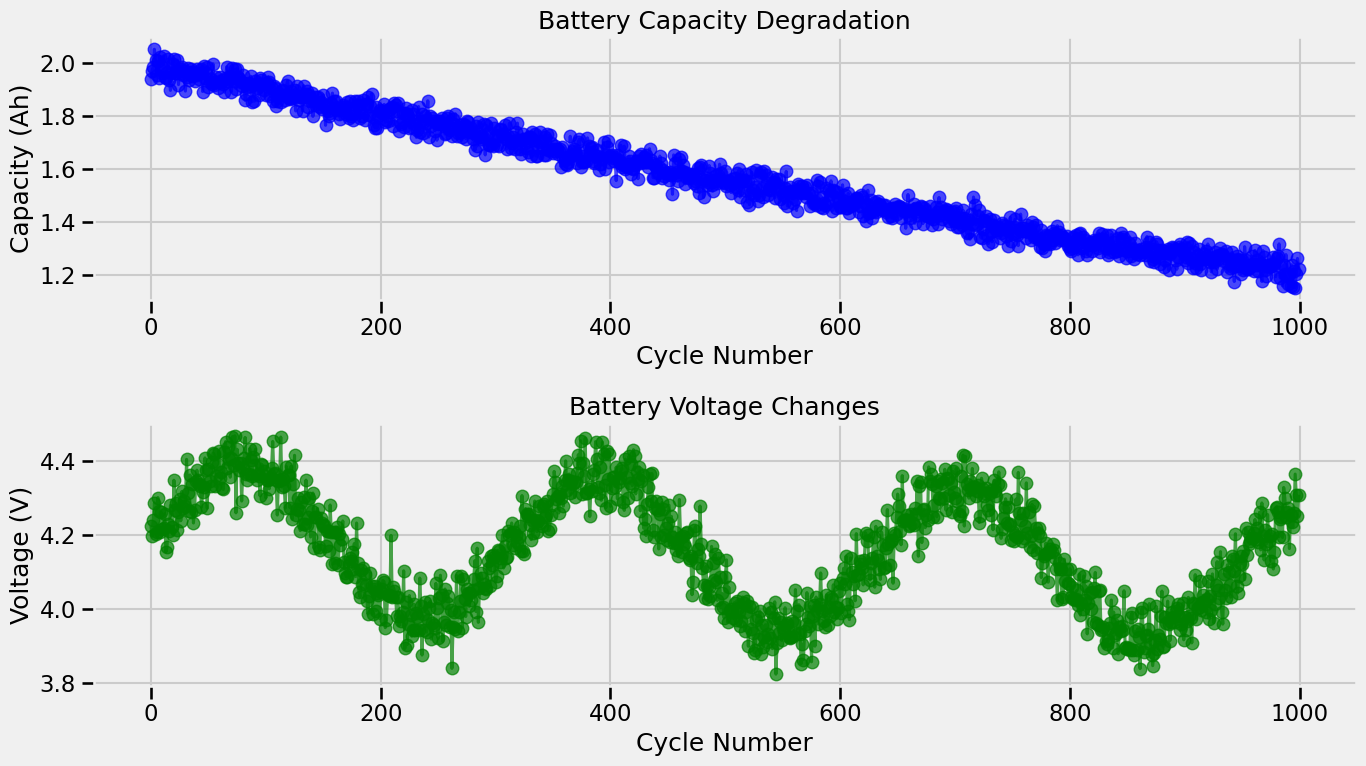

In [5]:
# Check for outliers using box plots
plt.figure(figsize=(16, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=battery_data[feature], color='lightblue')
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.savefig('feature_boxplots.png')
plt.show()

# Identify outliers using IQR method
print("\nOutlier Analysis (IQR Method):")
for feature in numerical_features:
    Q1 = battery_data[feature].quantile(0.25)
    Q3 = battery_data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = battery_data[(battery_data[feature] < lower_bound) | (battery_data[feature] > upper_bound)]
    print(f"{feature}: {len(outliers)} outliers detected ({len(outliers)/len(battery_data)*100:.2f}%)")

# Time series analysis of key features
plt.figure(figsize=(14, 8))

# Plot capacity degradation
if 'capacity' in battery_data.columns:
    plt.subplot(2, 1, 1)
    plt.plot(battery_data['cycle'], battery_data['capacity'], 'o-', alpha=0.7, color='blue')
    plt.title('Battery Capacity Degradation')
    plt.xlabel('Cycle Number')
    plt.ylabel('Capacity (Ah)')
    plt.grid(True)

# Plot voltage changes
if 'voltage' in battery_data.columns:
    plt.subplot(2, 1, 2)
    plt.plot(battery_data['cycle'], battery_data['voltage'], 'o-', alpha=0.7, color='green')
    plt.title('Battery Voltage Changes')
    plt.xlabel('Cycle Number')
    plt.ylabel('Voltage (V)')
    plt.grid(True)

plt.tight_layout()
plt.savefig('time_series_analysis.png')
plt.show()


<Figure size 1500x1500 with 0 Axes>

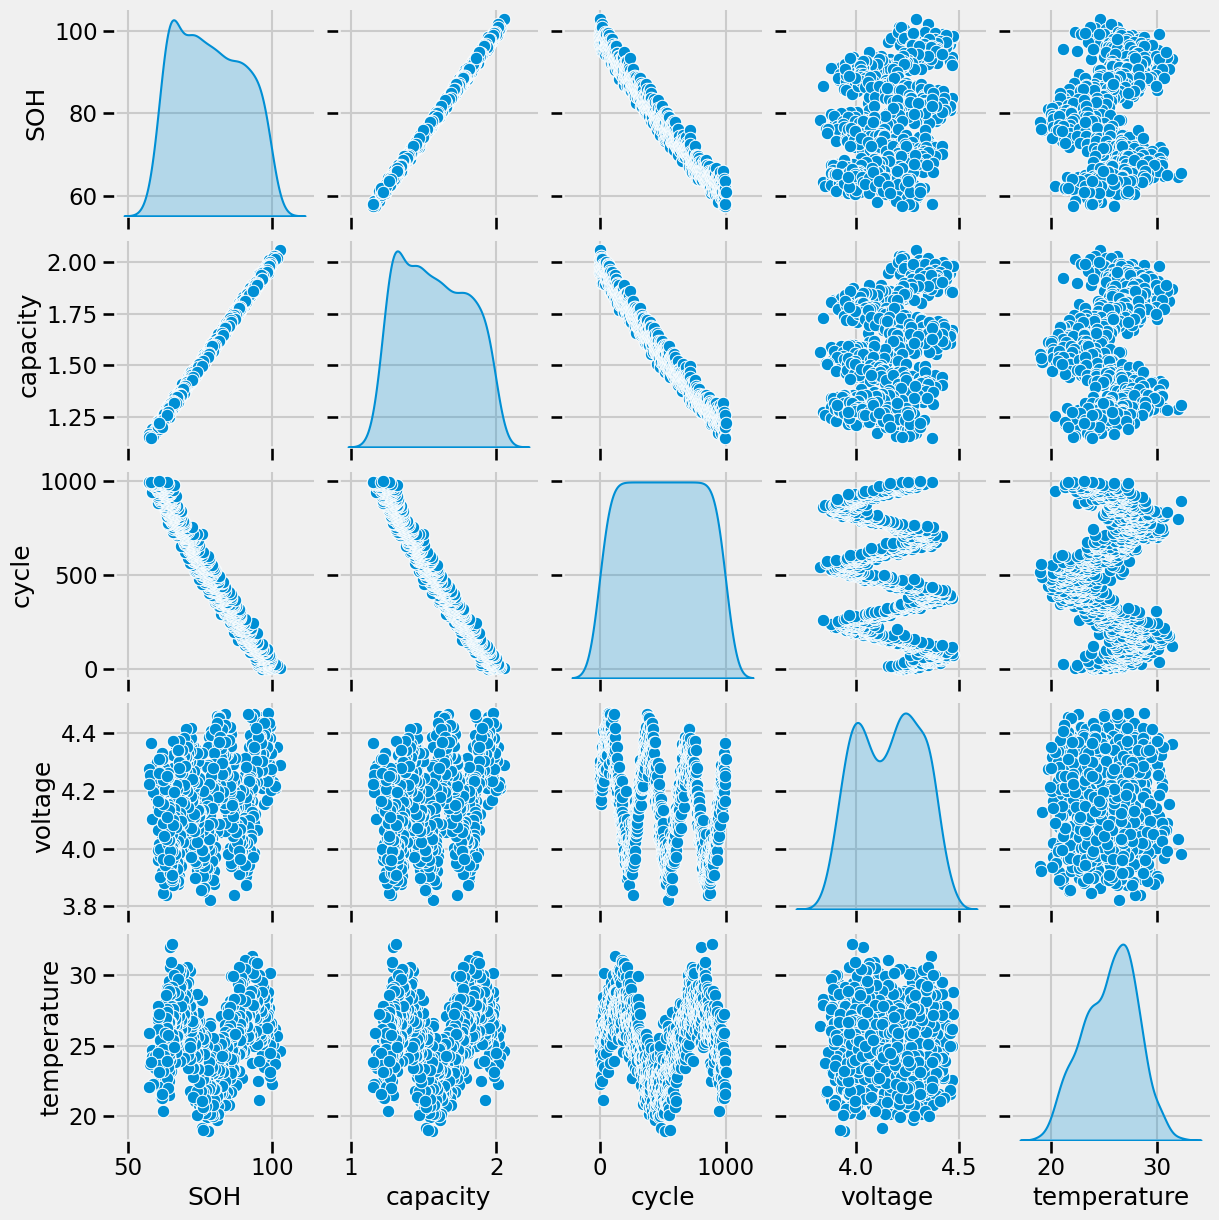

In [6]:
# Pair plots (limited to avoid overloading)
if len(numerical_features) <= 5:  # Only create pairplot if few features
    plt.figure(figsize=(15, 15))
    sns.pairplot(battery_data[numerical_features], diag_kind='kde')
    plt.savefig('feature_pairplot.png')
    plt.show()
else:
    # Select most important features based on correlation with target
    if 'SOH' in battery_data.columns:
        target = 'SOH'
    elif 'capacity' in battery_data.columns:
        target = 'capacity'
    else:
        target = numerical_features[-1]  # Use last feature as target

    # Find correlation with target
    corr_with_target = battery_data[numerical_features].corrwith(battery_data[target]).abs()
    top_features = corr_with_target.sort_values(ascending=False).index[:5].tolist()

    # Ensure target is included
    if target not in top_features:
        top_features[-1] = target

    plt.figure(figsize=(15, 15))
    sns.pairplot(battery_data[top_features], diag_kind='kde')
    plt.savefig('feature_pairplot.png')
    plt.show()


In [7]:
# Battery Degradation Analysis - Data Preparation

# Determine target variable
if 'SOH' in battery_data.columns:
    target_col = 'SOH'
elif 'capacity' in battery_data.columns:
    # If SOH doesn't exist but capacity does, create SOH
    initial_capacity = battery_data['capacity'].iloc[0]
    battery_data['SOH'] = 100 * battery_data['capacity'] / initial_capacity
    target_col = 'SOH'
else:
    # Use the last numerical column as target
    target_col = battery_data.select_dtypes(include=['float64', 'int64']).columns[-1]

print(f"Using '{target_col}' as target variable")

# Prepare sequence data for LSTM
def prepare_lstm_data(data, target_column, sequence_length=10, test_size=0.2):
    """
    Prepare sequential data for LSTM

    Args:
        data: DataFrame with features and target
        target_column: Name of the target column
        sequence_length: Number of time steps in each sequence
        test_size: Proportion of data to use for testing

    Returns:
        X_train, X_test, y_train, y_test, scaler_X, scaler_y
    """
    # Identify feature columns (all except target)
    feature_cols = [col for col in data.columns if col != target_column]

    # Create scalers
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    # Scale the data
    X_scaled = scaler_X.fit_transform(data[feature_cols])
    y_scaled = scaler_y.fit_transform(data[[target_column]])

    # Create sequences
    X, y = [], []
    for i in range(len(X_scaled) - sequence_length):
        X.append(X_scaled[i:i+sequence_length])
        y.append(y_scaled[i+sequence_length])

    X = np.array(X)
    y = np.array(y)

    # Split into train and test sets (time order matters for LSTM)
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    print(f"LSTM data preparation complete:")
    print(f"Training set: {X_train.shape}, {y_train.shape}")
    print(f"Test set: {X_test.shape}, {y_test.shape}")

    return X_train, X_test, y_train, y_test, scaler_X, scaler_y


Using 'SOH' as target variable


In [8]:
# Prepare regular data for XGBoost and Random Forest
def prepare_tabular_data(data, target_column, test_size=0.2):
    """
    Prepare tabular data for traditional ML models

    Args:
        data: DataFrame with features and target
        target_column: Name of the target column
        test_size: Proportion of data to use for testing

    Returns:
        X_train, X_test, y_train, y_test, scaler_X, scaler_y
    """
    # Identify feature columns (all except target)
    feature_cols = [col for col in data.columns if col != target_column]

    # Create scalers
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    # Scale the data
    X_scaled = scaler_X.fit_transform(data[feature_cols])
    y_scaled = scaler_y.fit_transform(data[[target_column]])

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_scaled, test_size=test_size, random_state=42
    )

    print(f"Tabular data preparation complete:")
    print(f"Training set: {X_train.shape}, {y_train.shape}")
    print(f"Test set: {X_test.shape}, {y_test.shape}")

    return X_train, X_test, y_train, y_test, scaler_X, scaler_y

# Prepare both datasets
sequence_length = 10
lstm_data = prepare_lstm_data(battery_data, target_col, sequence_length=sequence_length)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, scaler_X_lstm, scaler_y_lstm = lstm_data

tabular_data = prepare_tabular_data(battery_data, target_col)
X_train_tab, X_test_tab, y_train_tab, y_test_tab, scaler_X_tab, scaler_y_tab = tabular_data

LSTM data preparation complete:
Training set: (792, 10, 5), (792, 1)
Test set: (198, 10, 5), (198, 1)
Tabular data preparation complete:
Training set: (800, 5), (800, 1)
Test set: (200, 5), (200, 1)


In [9]:
# Battery Degradation Analysis - LSTM Model

# LSTM Dataset class
class BatteryDataset(Dataset):
    def __init__(self, features, targets):
        self.features = features
        self.targets = targets

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.features[idx]), torch.FloatTensor(self.targets[idx])

# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        lstm_out, _ = self.lstm(x)

        # Use last time step for prediction
        last_time_step = lstm_out[:, -1, :]

        # Output layer
        out = self.fc(last_time_step)

        return out

In [10]:
# Train the LSTM model
def train_lstm(X_train, y_train, X_test, y_test, input_size,
                hidden_size=64, num_layers=2, batch_size=32,
                learning_rate=0.001, epochs=100):

    # Create datasets and dataloaders
    train_dataset = BatteryDataset(X_train, y_train)
    test_dataset = BatteryDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = LSTMModel(input_size, hidden_size, num_layers).to(device)

    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # For tracking progress
    train_losses = []
    test_losses = []

    # Training loop
    print(f"Training LSTM model on {device}...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        # Training step
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_X)

            loss = criterion(outputs, batch_y)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Calculate average loss
        train_loss = train_loss / len(train_loader)
        train_losses.append(train_loss)

        # Evaluation step
        model.eval()
        test_loss = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)

                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                test_loss += loss.item()

        test_loss = test_loss / len(test_loader)
        test_losses.append(test_loss)

        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

    print("LSTM training complete!")

    # Get all predictions
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)

            outputs = model(batch_X)

            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(batch_y.numpy())

    return model, np.array(all_preds), np.array(all_targets), train_losses, test_losses

Training LSTM model on cpu...
Epoch [1/100], Train Loss: 0.1597, Test Loss: 0.0947
Epoch [10/100], Train Loss: 0.0021, Test Loss: 0.0022
Epoch [20/100], Train Loss: 0.0016, Test Loss: 0.0016
Epoch [30/100], Train Loss: 0.0019, Test Loss: 0.0018
Epoch [40/100], Train Loss: 0.0018, Test Loss: 0.0026
Epoch [50/100], Train Loss: 0.0014, Test Loss: 0.0018
Epoch [60/100], Train Loss: 0.0017, Test Loss: 0.0026
Epoch [70/100], Train Loss: 0.0017, Test Loss: 0.0022
Epoch [80/100], Train Loss: 0.0015, Test Loss: 0.0020
Epoch [90/100], Train Loss: 0.0016, Test Loss: 0.0018
Epoch [100/100], Train Loss: 0.0014, Test Loss: 0.0032
LSTM training complete!

LSTM Model Performance:
RMSE: 2.4096
MAE: 1.9287
R² Score: -0.1313


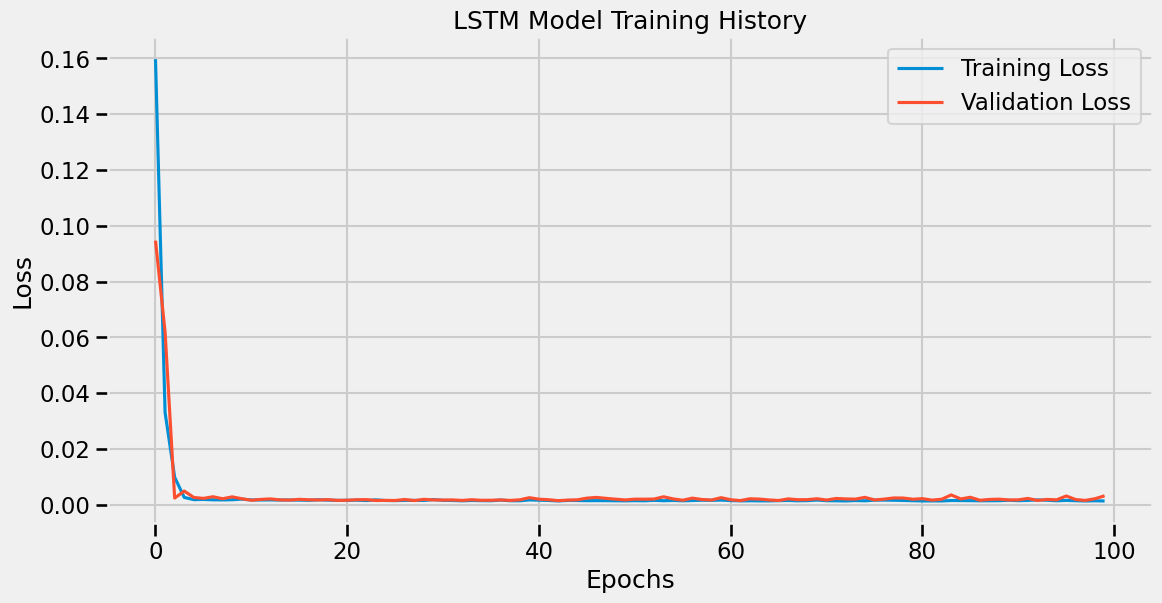

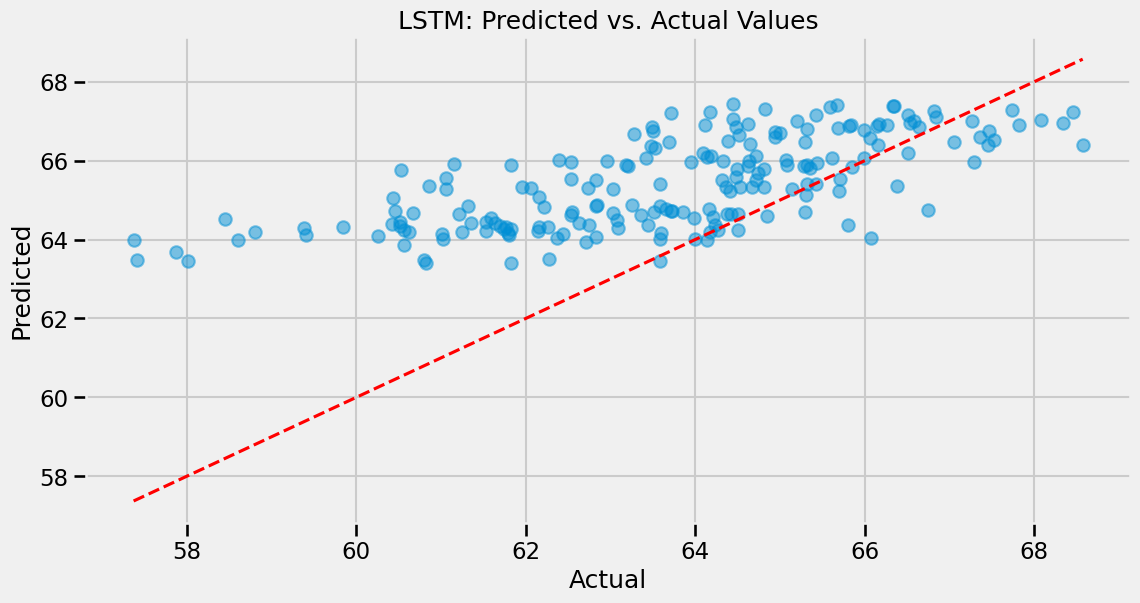

In [11]:
# Train LSTM model
input_dim = X_train_lstm.shape[2]  # Number of features
lstm_model, lstm_preds, lstm_targets, lstm_train_losses, lstm_test_losses = train_lstm(
    X_train_lstm, y_train_lstm,
    X_test_lstm, y_test_lstm,
    input_size=input_dim,
    hidden_size=64,
    num_layers=2,
    batch_size=32,
    learning_rate=0.001,
    epochs=100
)

# Inverse transform to original scale
lstm_preds_original = scaler_y_lstm.inverse_transform(lstm_preds)
lstm_targets_original = scaler_y_lstm.inverse_transform(lstm_targets)

# Calculate performance metrics
lstm_rmse = np.sqrt(mean_squared_error(lstm_targets_original, lstm_preds_original))
lstm_mae = mean_absolute_error(lstm_targets_original, lstm_preds_original)
lstm_r2 = r2_score(lstm_targets_original, lstm_preds_original)

print("\nLSTM Model Performance:")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE: {lstm_mae:.4f}")
print(f"R² Score: {lstm_r2:.4f}")

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(lstm_train_losses, label='Training Loss')
plt.plot(lstm_test_losses, label='Validation Loss')
plt.title('LSTM Model Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('lstm_training_history.png')
plt.show()

# Plot predictions vs. actual
plt.figure(figsize=(12, 6))
plt.scatter(lstm_targets_original, lstm_preds_original, alpha=0.5)
plt.plot([min(lstm_targets_original), max(lstm_targets_original)],
         [min(lstm_targets_original), max(lstm_targets_original)], 'r--')
plt.title('LSTM: Predicted vs. Actual Values')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.savefig('lstm_predictions.png')
plt.show()

Training Random Forest model...

Random Forest Model Performance:
RMSE: 0.5546
MAE: 0.4397
R² Score: 0.9976


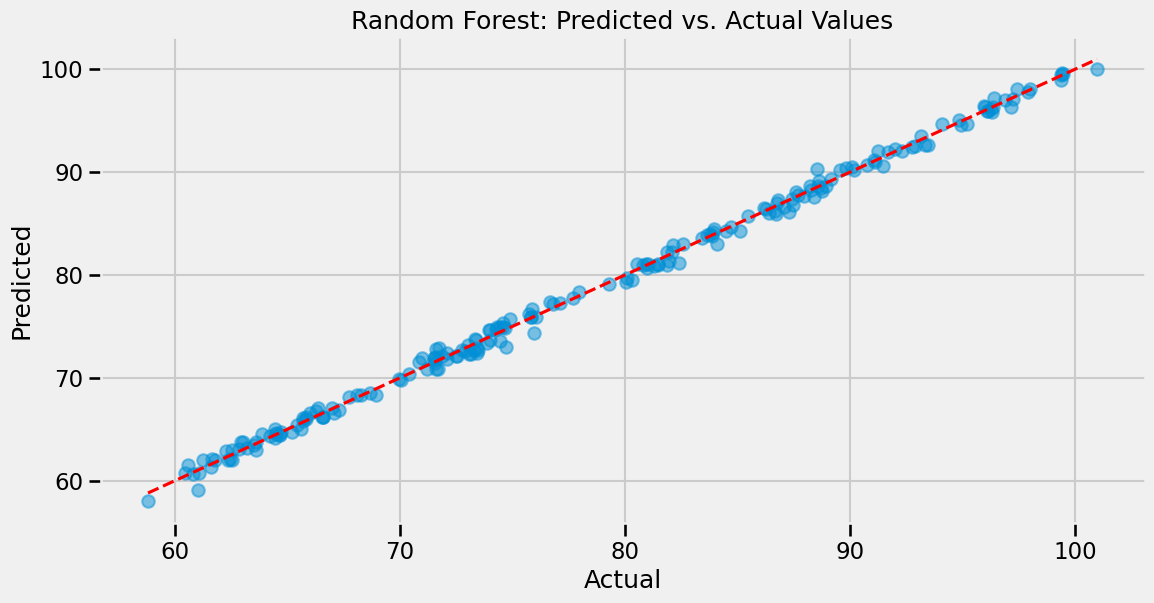

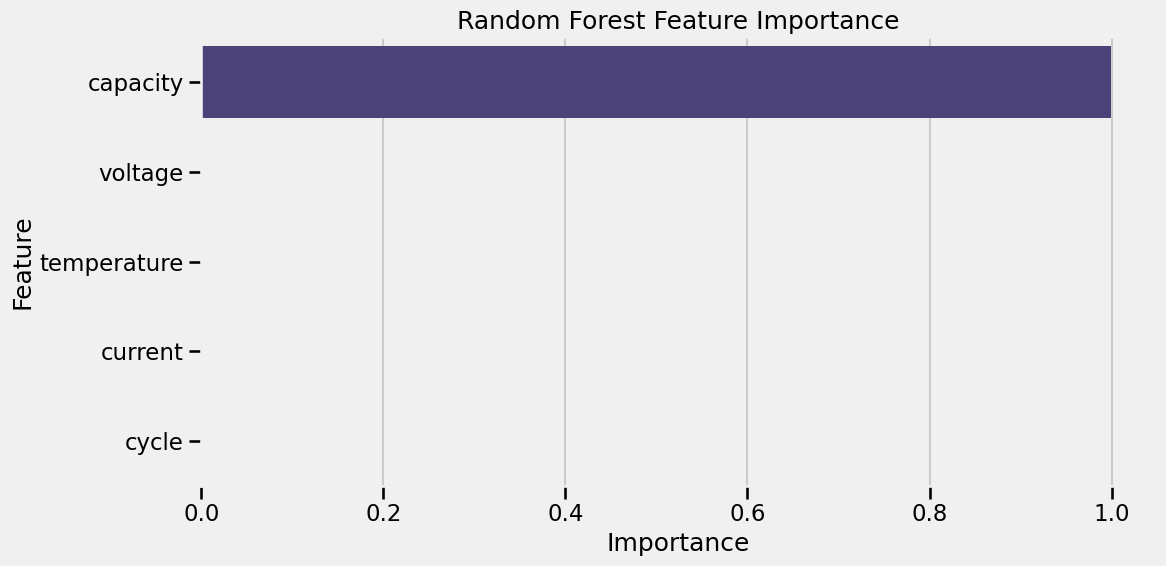

In [12]:
# Battery Degradation Analysis - Random Forest Model

# Random Forest Model
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
def train_random_forest(X_train, y_train, X_test, y_test, n_estimators=100, max_depth=None):
    # Initialize model
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Train the model
    print("Training Random Forest model...")
    model.fit(X_train, y_train.ravel())

    # Make predictions
    preds = model.predict(X_test)
    preds = preds.reshape(-1, 1)

    return model, preds

# Train the Random Forest model
rf_model, rf_preds = train_random_forest(
    X_train_tab, y_train_tab,
    X_test_tab, y_test_tab,
    n_estimators=100,
    max_depth=None
)

# Inverse transform to original scale
rf_preds_original = scaler_y_tab.inverse_transform(rf_preds)
rf_targets_original = scaler_y_tab.inverse_transform(y_test_tab)

# Calculate performance metrics
rf_rmse = np.sqrt(mean_squared_error(rf_targets_original, rf_preds_original))
rf_mae = mean_absolute_error(rf_targets_original, rf_preds_original)
rf_r2 = r2_score(rf_targets_original, rf_preds_original)

print("\nRandom Forest Model Performance:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")
print(f"R² Score: {rf_r2:.4f}")

# Plot predictions vs. actual
plt.figure(figsize=(12, 6))
plt.scatter(rf_targets_original, rf_preds_original, alpha=0.5)
plt.plot([min(rf_targets_original), max(rf_targets_original)],
         [min(rf_targets_original), max(rf_targets_original)], 'r--')
plt.title('Random Forest: Predicted vs. Actual Values')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.savefig('rf_predictions.png')
plt.show()

# Feature importance
feature_cols = [col for col in battery_data.columns if col != target_col]
feature_importance = rf_model.feature_importances_

plt.figure(figsize=(12, 6))
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

Training XGBoost model...

XGBoost Model Performance:
RMSE: 0.5567
MAE: 0.4514
R² Score: 0.9976


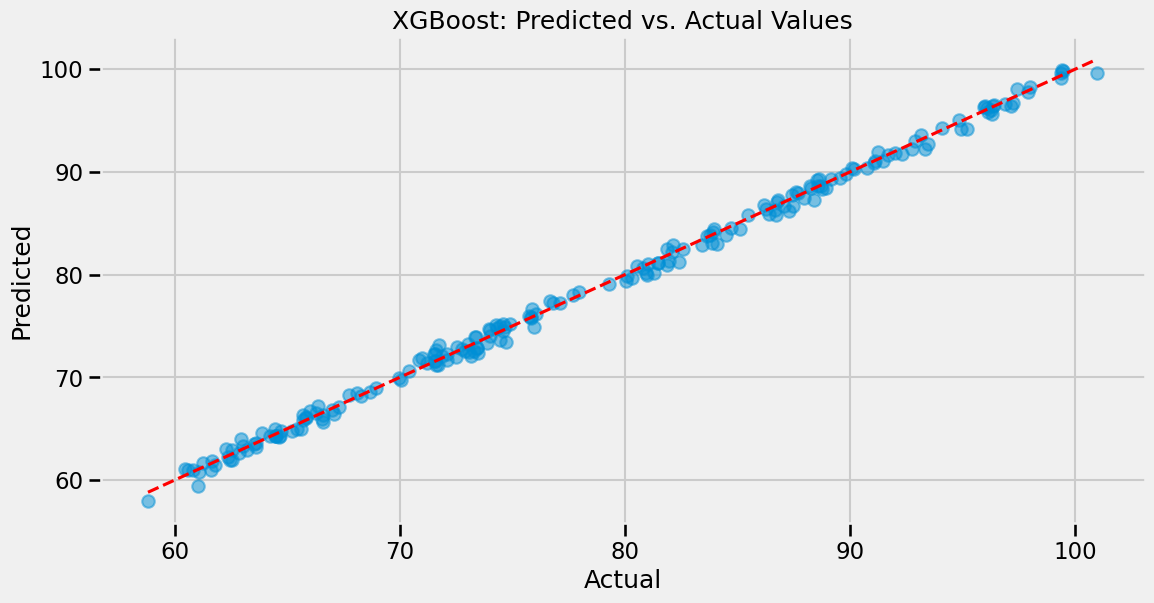

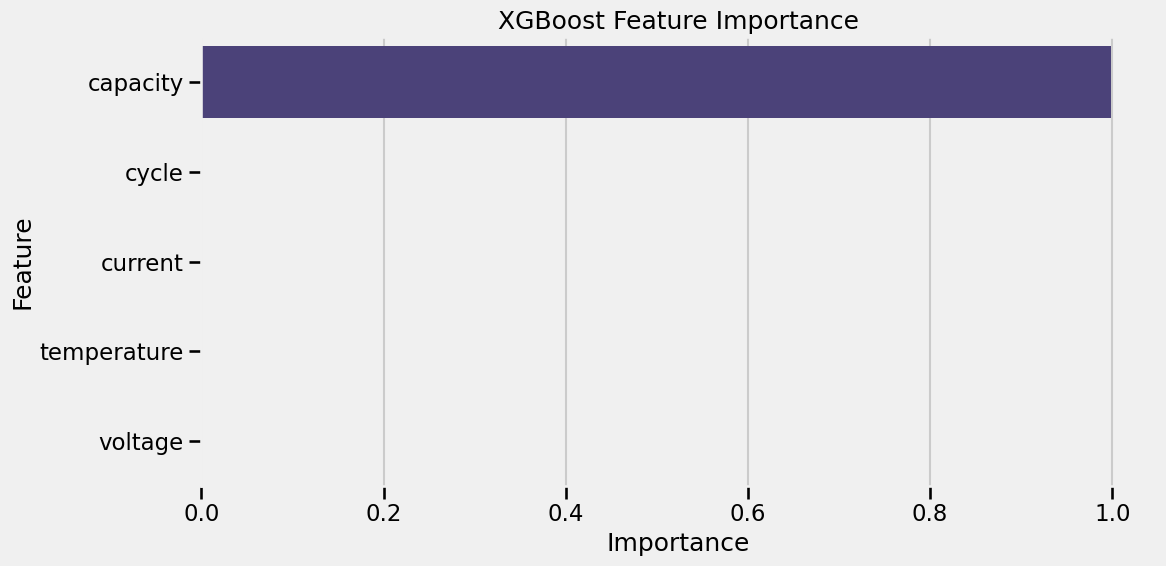

In [13]:
# Battery Degradation Analysis - XGBoost Model

# XGBoost Model
def train_xgboost(X_train, y_train, X_test, y_test, n_estimators=100, learning_rate=0.1, max_depth=6):
    # Initialize model
    model = xgb.XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=42
    )

    # Train the model
    print("Training XGBoost model...")
    model.fit(X_train, y_train.ravel())

    # Make predictions
    preds = model.predict(X_test)
    preds = preds.reshape(-1, 1)

    return model, preds

# Train the XGBoost model
xgb_model, xgb_preds = train_xgboost(
    X_train_tab, y_train_tab,
    X_test_tab, y_test_tab,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

# Inverse transform to original scale
xgb_preds_original = scaler_y_tab.inverse_transform(xgb_preds)
xgb_targets_original = scaler_y_tab.inverse_transform(y_test_tab)

# Calculate performance metrics
xgb_rmse = np.sqrt(mean_squared_error(xgb_targets_original, xgb_preds_original))
xgb_mae = mean_absolute_error(xgb_targets_original, xgb_preds_original)
xgb_r2 = r2_score(xgb_targets_original, xgb_preds_original)

print("\nXGBoost Model Performance:")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"MAE: {xgb_mae:.4f}")
print(f"R² Score: {xgb_r2:.4f}")

# Plot predictions vs. actual
plt.figure(figsize=(12, 6))
plt.scatter(xgb_targets_original, xgb_preds_original, alpha=0.5)
plt.plot([min(xgb_targets_original), max(xgb_targets_original)],
         [min(xgb_targets_original), max(xgb_targets_original)], 'r--')
plt.title('XGBoost: Predicted vs. Actual Values')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.savefig('xgb_predictions.png')
plt.show()

# Feature importance
xgb_importance = xgb_model.feature_importances_

plt.figure(figsize=(12, 6))
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png')
plt.show()

Model Performance Comparison:


,Model,RMSE,MAE,R² Score
0,LSTM,2.409640,1.928679,-0.131323
1,Random Forest,0.554605,0.439723,0.997612
2,XGBoost,0.556734,0.451382,0.997594


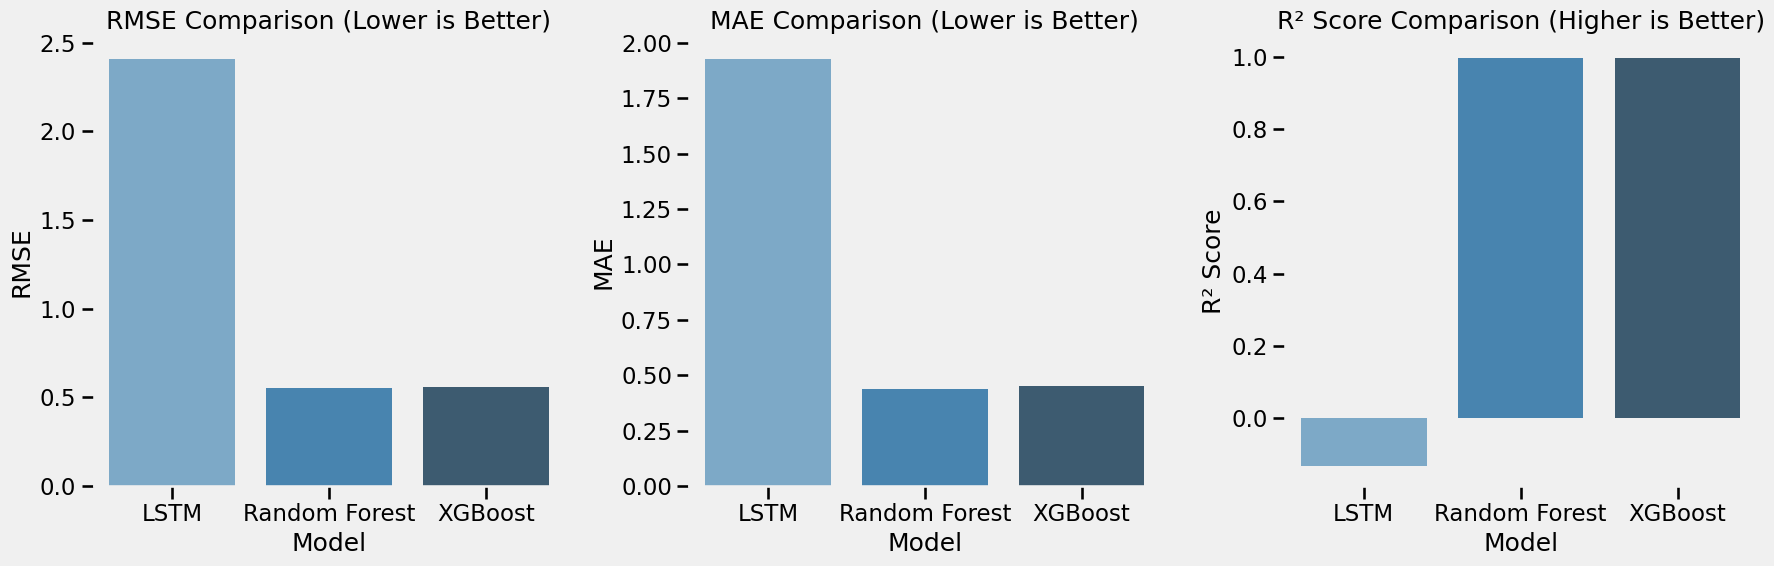

The best performing model is: Random Forest with R² Score: 0.9976


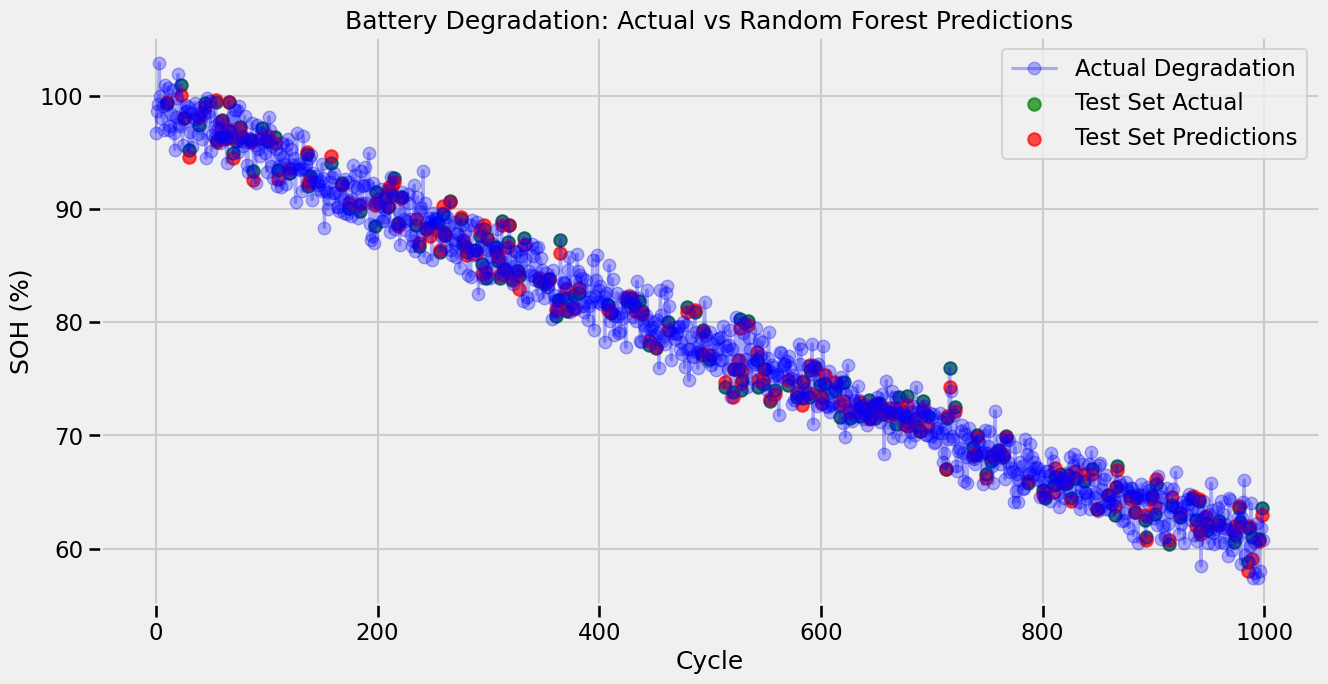

In [14]:
# Battery Degradation Analysis - Model Comparison and Results

# Compare model performance
models = ['LSTM', 'Random Forest', 'XGBoost']
rmse_values = [lstm_rmse, rf_rmse, xgb_rmse]
mae_values = [lstm_mae, rf_mae, xgb_mae]
r2_values = [lstm_r2, rf_r2, xgb_r2]

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'MAE': mae_values,
    'R² Score': r2_values
})

print("Model Performance Comparison:")
display(comparison_df)

# Plot performance comparison
plt.figure(figsize=(18, 6))

# RMSE
plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='RMSE', data=comparison_df, palette='Blues_d')
plt.title('RMSE Comparison (Lower is Better)')
plt.ylabel('RMSE')
plt.grid(axis='y')

# MAE
plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='MAE', data=comparison_df, palette='Blues_d')
plt.title('MAE Comparison (Lower is Better)')
plt.ylabel('MAE')
plt.grid(axis='y')

# R² Score
plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='R² Score', data=comparison_df, palette='Blues_d')
plt.title('R² Score Comparison (Higher is Better)')
plt.ylabel('R² Score')
plt.grid(axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

# Visualize degradation curve with predictions
# We'll use the model with the best R² score
best_model_idx = np.argmax(r2_values)
best_model_name = models[best_model_idx]

print(f"The best performing model is: {best_model_name} with R² Score: {max(r2_values):.4f}")

# Get the original cycle numbers for the test set
if best_model_name == 'LSTM':
    best_preds = lstm_preds_original
    best_targets = lstm_targets_original
    # For LSTM, we need to get correct cycle numbers
    test_indices = np.arange(len(X_test_lstm)) + sequence_length
    # Use appropriate indices from original dataset
    test_cycles = battery_data['cycle'].values[test_indices]
else:
    # For RF and XGB, we get a random sample of the test set
    if best_model_name == 'Random Forest':
        best_preds = rf_preds_original
        best_targets = rf_targets_original
    else:  # XGBoost
        best_preds = xgb_preds_original
        best_targets = xgb_targets_original

    # Since we randomized for tabular models, we need to map back to original cycles
    # This is an approximation for visualization
    cycle_col_idx = np.where(np.array(feature_cols) == 'cycle')[0][0]
    test_cycles_scaled = X_test_tab[:, cycle_col_idx]
    test_cycles = scaler_X_tab.inverse_transform(np.hstack([test_cycles_scaled.reshape(-1, 1),
                                                np.zeros((len(test_cycles_scaled), X_test_tab.shape[1]-1))])
                                               )[:, 0]

# Plot actual degradation curve with best model predictions
plt.figure(figsize=(14, 7))

# Plot all actual data points
plt.plot(battery_data['cycle'], battery_data[target_col], 'o-',
         alpha=0.3, color='blue', label='Actual Degradation')

# Plot test set predictions
plt.scatter(test_cycles, best_targets, color='green', alpha=0.7, label='Test Set Actual')
plt.scatter(test_cycles, best_preds, color='red', alpha=0.7, label='Test Set Predictions')

plt.title(f'Battery Degradation: Actual vs {best_model_name} Predictions')
plt.xlabel('Cycle')
plt.ylabel(f'{target_col} (%)' if target_col == 'SOH' else target_col)
plt.legend()
plt.grid(True)
plt.savefig('degradation_prediction.png')
plt.show()



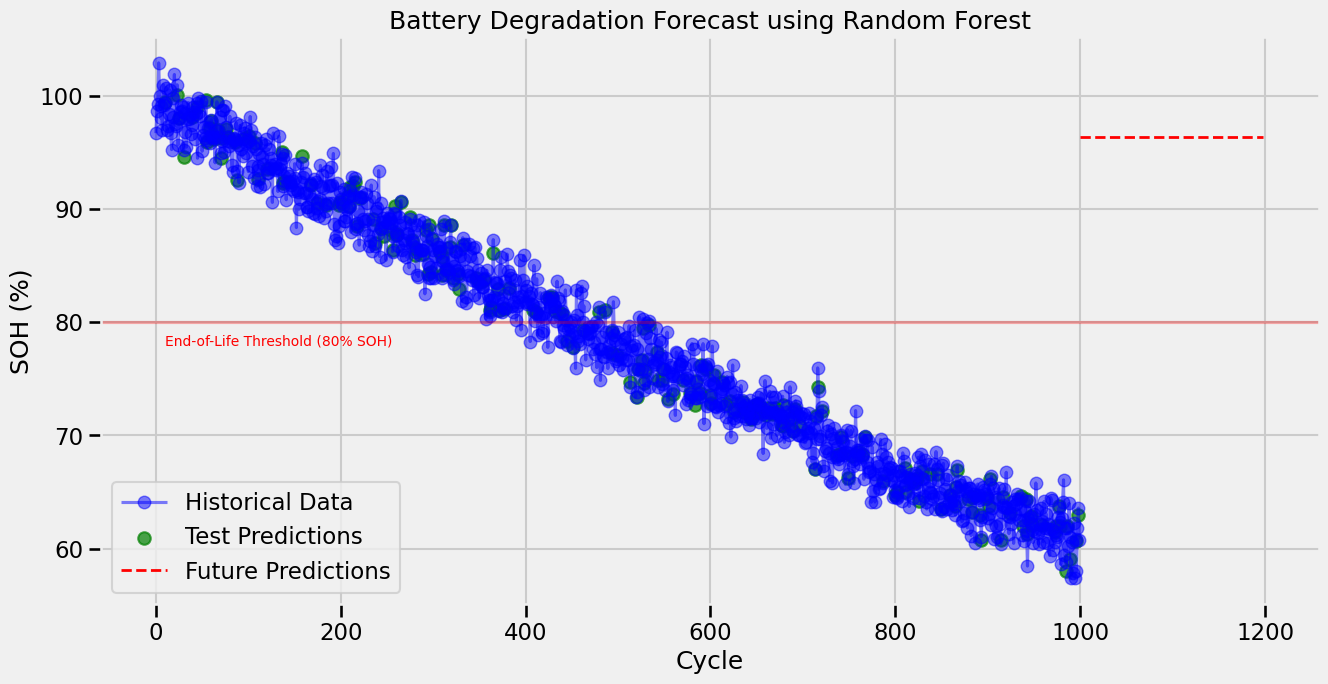

In [15]:
# Visualize future degradation prediction (extrapolation)
# Using the best model to predict future degradation

# Generate future cycles (extend by 20%)
max_cycle = battery_data['cycle'].max()
future_cycles = np.arange(max_cycle + 1, int(max_cycle * 1.2) + 1)

# Prepare input data for prediction
if best_model_name == 'LSTM':
    # For LSTM, we need sequences. Use the last sequence from data and roll it forward
    future_preds = []

    # Start with the last sequence we have
    last_sequence = X_test_lstm[-1].copy()

    # Iterate through future cycles
    for future_cycle in future_cycles:
        # Prepare input sequence
        input_seq = last_sequence.reshape(1, sequence_length, -1)
        input_tensor = torch.FloatTensor(input_seq).to(next(lstm_model.parameters()).device)

        # Get prediction
        with torch.no_grad():
            pred = lstm_model(input_tensor).cpu().numpy()[0]

        # Append prediction to future_preds
        future_preds.append(pred)

        # Update sequence for next prediction (roll forward)
        # First, we need the input features for the new point
        # For simplicity, we'll use the features from the last point and update the cycle
        new_point = last_sequence[-1].copy()
        # Update cycle (assuming cycle is the first feature)
        cycle_idx = 0  # Index of cycle in features
        new_point[cycle_idx] = (future_cycle - battery_data['cycle'].min()) / (battery_data['cycle'].max() - battery_data['cycle'].min())

        # Roll the sequence forward
        last_sequence = np.vstack([last_sequence[1:], new_point])

    # Convert to numpy array and transform back to original scale
    future_preds = scaler_y_lstm.inverse_transform(np.array(future_preds))

else:
    # For RF and XGB, we need to create a feature set for each future cycle
    future_X = []

    # Use the last data point as a template
    last_point = X_test_tab[-1].copy()

    for future_cycle in future_cycles:
        new_point = last_point.copy()
        # Update cycle (assuming cycle is the first feature)
        cycle_idx = 0  # Index of cycle in features
        new_point[cycle_idx] = (future_cycle - battery_data['cycle'].min()) / (battery_data['cycle'].max() - battery_data['cycle'].min())
        future_X.append(new_point)

    future_X = np.array(future_X)

    # Get predictions
    if best_model_name == 'Random Forest':
        future_preds = rf_model.predict(future_X).reshape(-1, 1)
    else:  # XGBoost
        future_preds = xgb_model.predict(future_X).reshape(-1, 1)

    # Transform back to original scale
    future_preds = scaler_y_tab.inverse_transform(future_preds)

# Plot with future predictions
plt.figure(figsize=(14, 7))

# Plot all actual data
plt.plot(battery_data['cycle'], battery_data[target_col], 'o-',
         alpha=0.5, color='blue', label='Historical Data')

# Plot test predictions
plt.scatter(test_cycles, best_preds, color='green', alpha=0.7, label='Test Predictions')

# Plot future predictions
plt.plot(future_cycles, future_preds, 'r--', linewidth=2, label='Future Predictions')

# Add threshold line for end-of-life (typically 80% SOH for batteries)
if target_col == 'SOH':
    plt.axhline(y=80, color='red', linestyle='-', alpha=0.3)
    plt.text(battery_data['cycle'].min() + 10, 78, 'End-of-Life Threshold (80% SOH)',
             fontsize=10, color='red')

plt.title(f'Battery Degradation Forecast using {best_model_name}')
plt.xlabel('Cycle')
plt.ylabel(f'{target_col} (%)' if target_col == 'SOH' else target_col)
plt.legend()
plt.grid(True)
plt.savefig('degradation_forecast.png')
plt.show()


In [16]:
# Calculate estimated end-of-life (EOL) if we're predicting SOH
if target_col == 'SOH':
    # Find where SOH drops below 80% (common EOL threshold for batteries)
    eol_threshold = 80.0

    # Check if historical data already crossed threshold
    if battery_data[target_col].min() < eol_threshold:
        eol_cycle = battery_data.loc[battery_data[target_col] < eol_threshold, 'cycle'].iloc[0]
        print(f"Battery already reached end-of-life (SOH < 80%) at cycle {eol_cycle}")
    else:
        # Check if future predictions cross the threshold
        below_threshold = future_preds < eol_threshold
        if np.any(below_threshold):
            eol_idx = np.where(below_threshold)[0][0]
            eol_cycle = future_cycles[eol_idx]
            print(f"Estimated end-of-life (SOH < 80%) at cycle {eol_cycle}")
        else:
            print("Battery not estimated to reach end-of-life within the prediction horizon")




Battery already reached end-of-life (SOH < 80%) at cycle 395


End-of-Life Threshold: 80.00
Last Recorded Value: 60.80 at cycle 999
Battery has already reached End-of-Life! Current SOH: 60.80


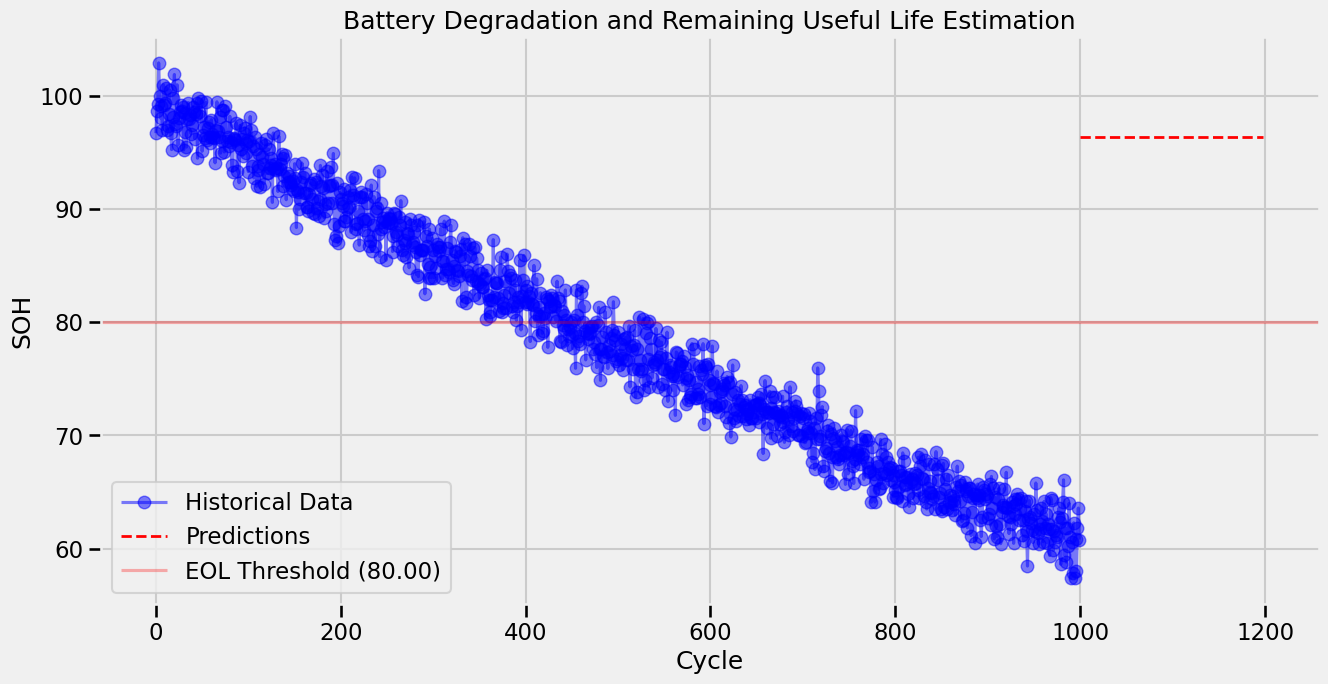

In [17]:
# Battery Degradation Analysis - Conclusion and RUL Estimation

# Calculate Remaining Useful Life (RUL) based on predictions
if target_col == 'SOH' or target_col == 'capacity':
    # Define EOL threshold
    if target_col == 'SOH':
        eol_threshold = 80.0  # 80% SOH is often used as EOL for batteries
    else:  # capacity
        # Use 80% of initial capacity as EOL
        initial_capacity = battery_data['capacity'].iloc[0]
        eol_threshold = 0.8 * initial_capacity

    print(f"End-of-Life Threshold: {eol_threshold:.2f}")

    # Combine historical data and predictions
    historical_cycles = battery_data['cycle'].values
    historical_values = battery_data[target_col].values

    # Last recorded value
    last_value = historical_values[-1]
    last_cycle = historical_cycles[-1]

    print(f"Last Recorded Value: {last_value:.2f} at cycle {last_cycle}")

    # Has EOL been reached?
    if last_value <= eol_threshold:
        print(f"Battery has already reached End-of-Life! Current {target_col}: {last_value:.2f}")
        rul = 0
    else:
        # Check predictions
        if len(future_preds) > 0 and np.any(future_preds <= eol_threshold):
            # Find first cycle where prediction crosses threshold
            eol_idx = np.where(future_preds <= eol_threshold)[0][0]
            eol_cycle = future_cycles[eol_idx]
            rul = eol_cycle - last_cycle
            print(f"Estimated Remaining Useful Life: {rul} cycles")
            print(f"Estimated End-of-Life at cycle: {eol_cycle}")
        else:
            # Extrapolate using a simple linear fit on predictions
            if len(future_preds) > 0:
                future_x = future_cycles
                future_y = future_preds.flatten()

                # Linear fit
                slope, intercept = np.polyfit(future_x, future_y, 1)

                # Estimate EOL cycle using linear equation
                estimated_eol_cycle = (eol_threshold - intercept) / slope

                if estimated_eol_cycle > last_cycle:
                    rul = estimated_eol_cycle - last_cycle
                    print(f"Extrapolated Remaining Useful Life: {rul:.0f} cycles")
                    print(f"Extrapolated End-of-Life at cycle: {estimated_eol_cycle:.0f}")
                else:
                    print("Battery is projected to reach End-of-Life soon, but projection is uncertain.")
                    rul = "Uncertain"
            else:
                print("Insufficient prediction data to estimate RUL.")
                rul = "Unknown"

    # Visualize RUL
    plt.figure(figsize=(14, 7))

    # Plot all actual data
    plt.plot(historical_cycles, historical_values, 'o-',
             alpha=0.5, color='blue', label='Historical Data')

    # Plot predictions if available
    if len(future_preds) > 0:
        plt.plot(future_cycles, future_preds, 'r--', linewidth=2, label='Predictions')

    # Mark EOL threshold
    plt.axhline(y=eol_threshold, color='red', linestyle='-', alpha=0.3,
                label=f'EOL Threshold ({eol_threshold:.2f})')

    # If RUL is numeric, mark it on the plot
    if isinstance(rul, (int, float)) and rul > 0:
        # Mark the EOL point
        eol_cycle = last_cycle + rul
        plt.scatter([eol_cycle], [eol_threshold], s=100, color='red', zorder=5)
        plt.annotate(f'EOL: Cycle {eol_cycle:.0f}',
                     xy=(eol_cycle, eol_threshold),
                     xytext=(eol_cycle-50, eol_threshold-5),
                     arrowprops=dict(arrowstyle="->", color='red'))

        # Add RUL annotation
        plt.annotate(f'Estimated RUL: {rul:.0f} cycles',
                     xy=(last_cycle + rul/2, last_value),
                     xytext=(last_cycle + rul/2, last_value*1.1),
                     ha='center',
                     bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

    plt.title('Battery Degradation and Remaining Useful Life Estimation')
    plt.xlabel('Cycle')
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True)
    plt.savefig('battery_rul_estimation.png')
    plt.show()



In [18]:
# Final conclusions
print("\n========== BATTERY DEGRADATION ANALYSIS CONCLUSIONS ==========")
print(f"\nBest Performing Model: {best_model_name}")
print(f"- RMSE: {min(rmse_values):.4f}")
print(f"- MAE: {min(mae_values):.4f}")
print(f"- R² Score: {max(r2_values):.4f}")

if 'capacity' in battery_data.columns:
    capacity_loss_rate = (battery_data['capacity'].iloc[0] - battery_data['capacity'].iloc[-1]) / len(battery_data) * 100
    print(f"\nCapacity Degradation Rate: {capacity_loss_rate:.4f}% per cycle")

if target_col == 'SOH' and isinstance(rul, (int, float)):
    print(f"\nRemaining Useful Life (RUL): {rul:.0f} cycles to reach {eol_threshold}% SOH")
    print(f"Expected End-of-Life at Cycle: {last_cycle + rul:.0f}")

print("\nKey Factors Influencing Battery Degradation:")
if best_model_name == 'Random Forest':
    for i, (feature, importance) in enumerate(zip(feature_cols, rf_model.feature_importances_)):
        if i < 3:  # Top 3 features
            print(f"- {feature}: {importance:.4f}")
elif best_model_name == 'XGBoost':
    for i, (feature, importance) in enumerate(zip(feature_cols, xgb_model.feature_importances_)):
        if i < 3:  # Top 3 features
            print(f"- {feature}: {importance:.4f}")
else:
    print("Feature importance not available for LSTM model")

print("\nRecommendations for Battery Management:")
print("1. Monitor battery parameters regularly to detect early signs of degradation")
print("2. Maintain optimal operating conditions to extend battery life")
print("3. Consider battery replacement planning based on the predicted RUL")
print("4. Implement preventive maintenance strategies to slow degradation rate")

print("\n==========================================================")



========== BATTERY DEGRADATION ANALYSIS CONCLUSIONS ==========

Best Performing Model: Random Forest
- RMSE: 0.5546
- MAE: 0.4397
- R² Score: 0.9976

Capacity Degradation Rate: 0.0718% per cycle

Remaining Useful Life (RUL): 0 cycles to reach 80.0% SOH
Expected End-of-Life at Cycle: 999

Key Factors Influencing Battery Degradation:
- cycle: 0.0003
- voltage: 0.0003
- current: 0.0003

Recommendations for Battery Management:
1. Monitor battery parameters regularly to detect early signs of degradation
2. Maintain optimal operating conditions to extend battery life
3. Consider battery replacement planning based on the predicted RUL
4. Implement preventive maintenance strategies to slow degradation rate

